In [20]:
import pandas as pd

X_train_pca = pd.read_csv("/home/sonu/code/ml/phisingdetector/data/x_train_pca.csv").to_numpy()
X_test_pca = pd.read_csv("/home/sonu/code/ml/phisingdetector/data/x_test_pca.csv").to_numpy()

y_train = pd.read_csv("/home/sonu/code/ml/phisingdetector/data/y_train.csv").to_numpy().ravel()
y_test = pd.read_csv("/home/sonu/code/ml/phisingdetector/data/y_test.csv").to_numpy().ravel()

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "SVM": SVC(
        C=1.0,
        random_state=42,
        max_iter=5000)
}

In [22]:
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    print(f"{name} trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained
SVM trained


In [23]:
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_pca)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, y_pred in predictions.items():

    print("\n", name)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1       :", f1_score(y_test, y_pred))


 Logistic Regression
Accuracy : 0.9971251548946716
Precision: 0.9971849865951743
Recall   : 0.9950508293204923
F1       : 0.9961167648634173

 Decision Tree
Accuracy : 0.9982156133828997
Precision: 0.997459213693501
Recall   : 0.9977260567148207
F1       : 0.9975926173599037

 Random Forest
Accuracy : 0.9990582403965304
Precision: 0.999865933771283
Recall   : 0.9975922953451043
F1       : 0.9987278205557415

 SVM
Accuracy : 0.9976703841387856
Precision: 0.99946214871588
Recall   : 0.9942482611021937
F1       : 0.9968483873130826


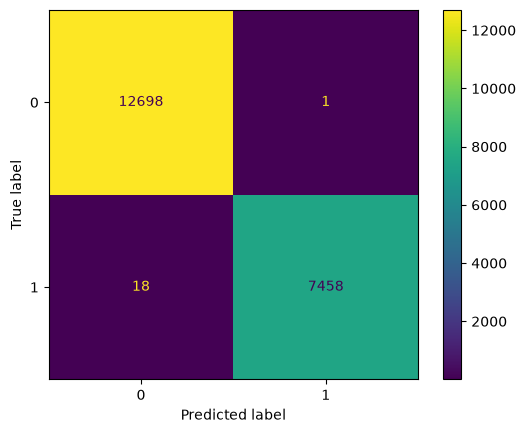

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = models["Random Forest"]

y_pred = model.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

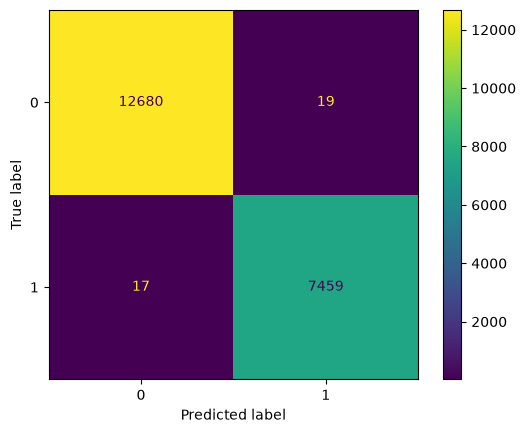

In [26]:
model = models["Decision Tree"]

y_pred = model.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

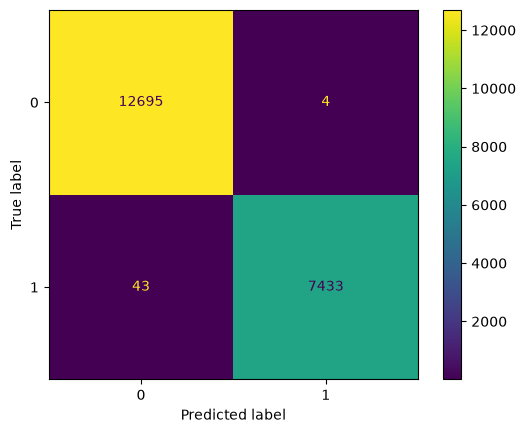

In [27]:
model = models["SVM"]

y_pred = model.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

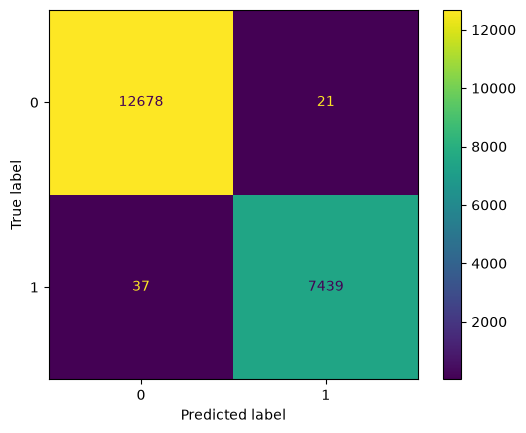

In [28]:
model = models["Logistic Regression"]

y_pred = model.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

In [29]:
from urllib.parse import urlparse

df = pd.read_csv("/home/sonu/code/ml/phisingdetector/data/urls1.csv")  # Replace with your actual data file
df.columns = df.columns.str.strip().str.lower()

df["domain"] = (
    df["url"]
    .fillna("")
    .astype(str)
    .apply(lambda x: urlparse(x).netloc.lower() if x else "")
)

print("Unique domains:", df["domain"].nunique())


Unique domains: 64072


In [30]:
train_domains = set(df.iloc[:X_train_pca.shape[0]]["domain"])
test_domains = set(df.iloc[X_train_pca.shape[0]:X_train_pca.shape[0] + X_test_pca.shape[0]]["domain"])


overlap = train_domains.intersection(test_domains)

print("Train domains:", len(train_domains))
print("Test domains:", len(test_domains))
print("Overlapping domains:", len(overlap))

print(
    "Overlap percentage:",
    len(overlap) / len(test_domains) * 100
)

Train domains: 43559
Test domains: 20175
Overlapping domains: 9
Overlap percentage: 0.04460966542750929


In [31]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train_pca,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\n{name}")
    print(f"Accuracy : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"Precision: {scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}")
    print(f"Recall   : {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")
    print(f"F1       : {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")


Logistic Regression
Accuracy : 0.9960 ± 0.0003
Precision: 0.9950 ± 0.0008
Recall   : 0.9943 ± 0.0005
F1       : 0.9947 ± 0.0004

Decision Tree
Accuracy : 0.9978 ± 0.0003
Precision: 0.9967 ± 0.0006
Recall   : 0.9973 ± 0.0012
F1       : 0.9970 ± 0.0004

Random Forest
Accuracy : 0.9987 ± 0.0004
Precision: 0.9997 ± 0.0001
Recall   : 0.9969 ± 0.0011
F1       : 0.9983 ± 0.0006

SVM
Accuracy : 0.9975 ± 0.0003
Precision: 0.9995 ± 0.0002
Recall   : 0.9939 ± 0.0007
F1       : 0.9967 ± 0.0004


In [32]:
import joblib
for name, model in models.items():
    joblib.dump(model, f"{name.replace(' ', '_').lower()}_model.pkl")